# 05 - Seasonal Trends & Visualization Analysis

An exploration of delivery performance patterns over time using matplotlib and seaborn visualizations,  specifically investigating the May–July 2024 performance dip identified in notebook 03 through histograms, scatter plots, box plots, and time-series trends.


## Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/Users/DianaLara/PycharmProjects/PythonLearning_DataAnalysis/Orders.csv', encoding='UTF-16', sep='\t')

df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True, errors='coerce')
df['Actual Delivery Date'] = pd.to_datetime(df['Actual Delivery Date'], dayfirst=True, errors='coerce')

sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)

df.head()


,Order ID,Actual Delivery Date,Delay Reason,Driver ID,Driver Name,Hub Name,Is Delayed,Is On Time,Order Date,Order Status,Vehicle Name,Vehicle Type,Customer Satisfaction Score,Delivery Time Hours,Hub Processing Time Hours
0,1,2024-10-25,NaN,43,Karen Rodriguez,San Antonio Hub,False,True,2024-10-25,Delivered,FT-036,Truck,4,6.81,0.89
1,2,2024-06-16,NaN,29,Matthew Williams,Houston Hub,False,True,2024-06-16,Delivered,FT-016,Van,4,5.74,3.60
2,3,2024-07-05,NaN,25,Nancy Harris,Austin Hub,False,True,2024-07-05,Delivered,FT-040,Van,4,12.91,2.07
3,4,2023-08-22,NaN,20,David Davis,Fort Worth Hub,False,True,2023-08-22,Delivered,FT-039,Van,5,9.40,2.37
4,5,2024-06-06,Severe Weather,49,Joseph Williams,Dallas Main Hub,True,False,2024-06-02,Delivered,FT-018,Truck,3,103.48,1.80


## 1. Data Preparation for Time-Series Analysis

In [3]:
df['Order Month'] = df['Order Date'].dt.to_period('M')

# Build monthly trends dataframe
monthly_trends = pd.DataFrame({
    'total_orders': df.groupby('Order Month').size(),
    'avg_delivery_hours': df.groupby('Order Month')['Delivery Time Hours'].mean(),
    'on_time_pct': df.groupby('Order Month')['Is On Time'].mean() * 100,
    'avg_satisfaction': df.groupby('Order Month')['Customer Satisfaction Score'].mean()
})

# Create flag for May-July 2024 (the period flagged as problematic in notebook 03)
df['is_may_july_2024'] = ((df['Order Month'] >= pd.Period('2024-05', freq='M')) & 
                          (df['Order Month'] <= pd.Period('2024-07', freq='M')))

print(f"May-July 2024 orders: {df['is_may_july_2024'].sum()} out of {len(df)} total")


May-July 2024 orders: 3608 out of 27979 total


## 2. Time-Series Line Plot

Monthly average delivery time across the full 24-month span, highlighting whether May-July 2024 stands out as a distinct peak or part of a broader trend.


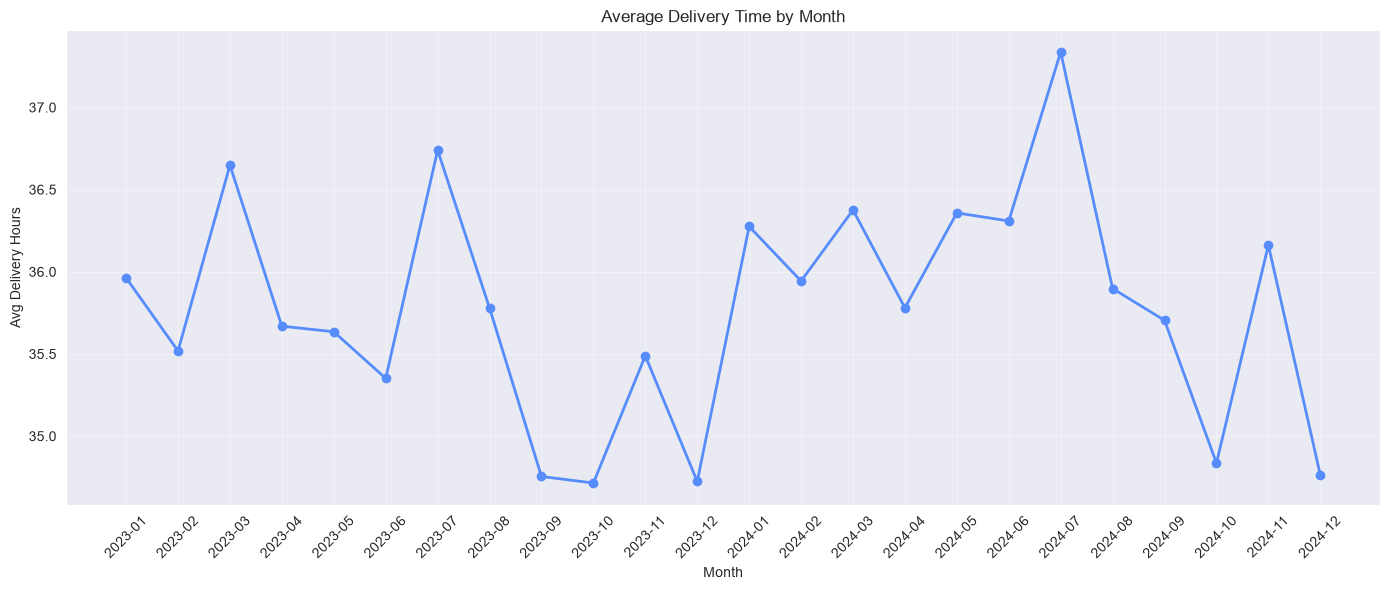

In [4]:
monthly_trends_plot = monthly_trends.reset_index()
monthly_trends_plot['Order Month'] = monthly_trends_plot['Order Month'].astype(str)

plt.figure(figsize=(14, 6))
plt.plot(monthly_trends_plot['Order Month'], monthly_trends_plot['avg_delivery_hours'], marker='o', linewidth=2)
plt.title('Average Delivery Time by Month')
plt.xlabel('Month')
plt.ylabel('Avg Delivery Hours')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Finding:** July 2024 stands out as a single peak at ~37.3 hours, the highest point in the entire 24-month dataset. May and June 2024 also show elevated levels, confirming notebook 03's finding that May-July 2024 was the roughest stretch. However, the variation is relatively modest (roughly 34.7-37.3 hours across all months). The entire dataset never strays far from the ~35.8 hour average.


## 3. Histogram: Distribution Comparison

Comparing the shape and spread of delivery times during May-July 2024 versus the rest of the dataset. This reveals whether the slowdown was a shift in the average, a change in spread, or both.


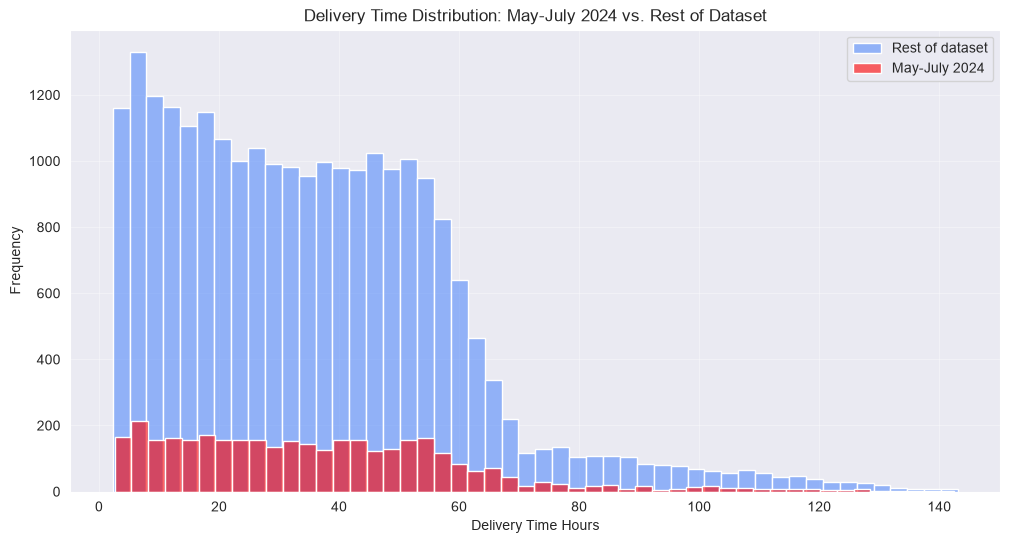

In [5]:
plt.figure(figsize=(12, 6))
sns.histplot(data=df[df['is_may_july_2024'] == False], x='Delivery Time Hours', bins=50, label='Rest of dataset', alpha=0.6)
sns.histplot(data=df[df['is_may_july_2024'] == True], x='Delivery Time Hours', bins=50, label='May-July 2024', alpha=0.6, color='red')
plt.title('Delivery Time Distribution: May-July 2024 vs. Rest of Dataset')
plt.xlabel('Delivery Time Hours')
plt.ylabel('Frequency')
plt.legend()
plt.show()


**Finding:** Both distributions are right-skewed and cluster heavily in the 0-60 hour range, with May-July 2024 (red) and the rest of the dataset (blue) showing similar *shapes*. May-July 2024 doesn't have a dramatically different distribution; instead, it shows a subtle **rightward shift** in central tendency. More deliveries landed in the 30-50 hour range during May-July 2024 than usual, pulling the average upward, rather than a flood of new extreme outliers appearing. This suggests the slowdown came from operational stress affecting typical deliveries, not a breakdown in the tail (which stayed roughly consistent).


## 4. Box Plot: Month-by-Month Spread

Examining the median, quartiles, and outliers for each month. This shows whether May-July 2024 had a fundamentally different spread of delivery times, or just a shifted central tendency.


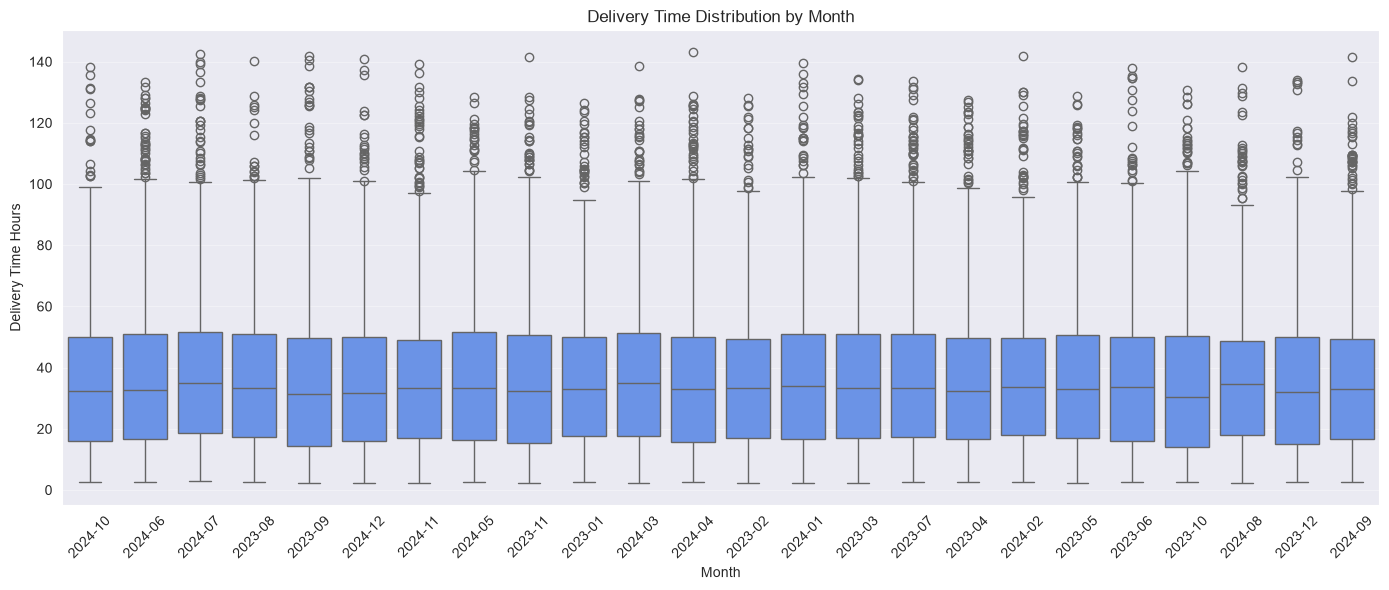

In [6]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x='Order Month', y='Delivery Time Hours')
plt.title('Delivery Time Distribution by Month')
plt.xlabel('Month')
plt.ylabel('Delivery Time Hours')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Finding:** the interquartile range (the box, representing the middle 50% of data) and medians (the line inside each box) remain fairly consistent across all months, including May-July 2024. The outliers (individual dots above each box) are present in all months at similar frequencies. This suggests **May-July 2024's higher average is not driven by the core distribution shifting**, but rather by a subtle rightward push in the typical deliveries, keeping the quartile structure stable while raising the mean.


## 5. Scatter Plot: Tipping-Point Relationship Over Time

Testing whether the delivery-time/satisfaction tipping point (identified in notebook 02 at 72 hours) held steady during May-July 2024, or whether the relationship fundamentally changed.


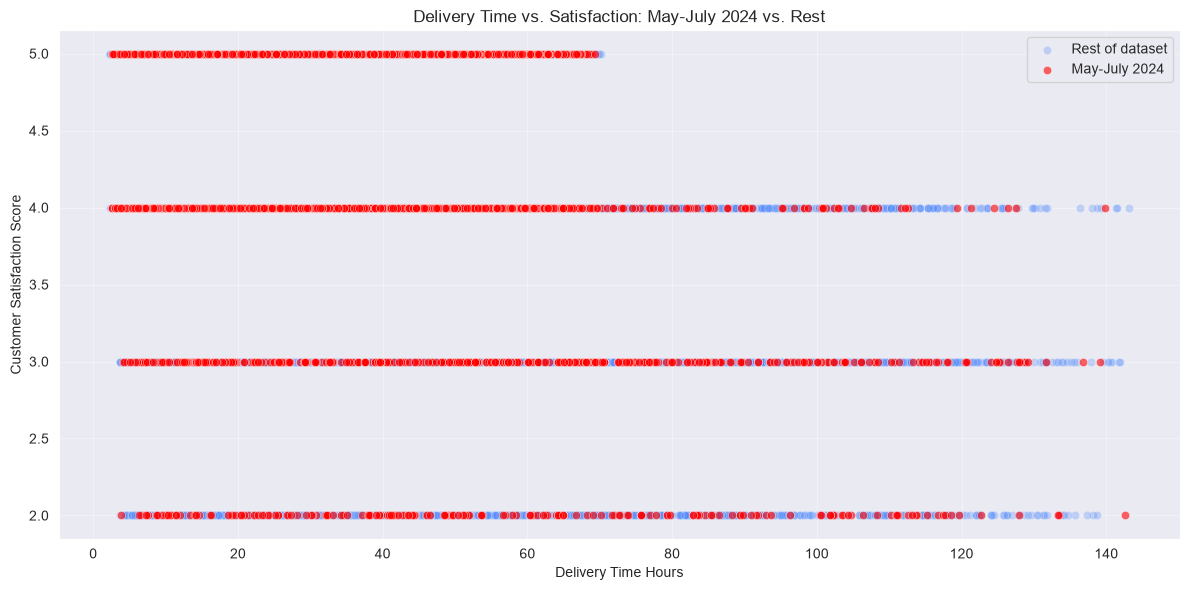

In [7]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df[df['is_may_july_2024'] == False], x='Delivery Time Hours', y='Customer Satisfaction Score', alpha=0.3, label='Rest of dataset')
sns.scatterplot(data=df[df['is_may_july_2024'] == True], x='Delivery Time Hours', y='Customer Satisfaction Score', alpha=0.6, color='red', label='May-July 2024')
plt.title('Delivery Time vs. Satisfaction: May-July 2024 vs. Rest')
plt.xlabel('Delivery Time Hours')
plt.ylabel('Customer Satisfaction Score')
plt.legend()
plt.tight_layout()
plt.show()


**Finding: Critical insight:** the red dots (May-July 2024) and blue dots (rest of dataset) follow the exact same satisfaction-drop pattern. The tipping point at 72 hours is evident in *both* groups, satisfaction is stable under 72 hours (~4.3-5.0 range), then drops to around 3.0 for 72-120 hour deliveries, then falls to ~2.0 for 120+ hours. This means **May-July 2024 was not a different operational regime**, but rather the same underlying delivery-satisfaction relationship playing out with more orders pushed into the problematic ranges.


## Summary of Key Findings

**Seasonal Pattern: May-July 2024 Dip**
- July 2024 hits the highest average delivery time (~37.3 hrs) in the entire 24-month dataset; May-June 2024 also elevated but less dramatic.
- The dip is **real but modest** — total variance across all months is only ~2.6 hours (34.7 to 37.3), so no month is extremelly different from the 35.8-hour average.

**Distribution Shape: Consistent, Not Broken**
- May-July 2024 does not have a fundamentally *different* distribution shape compared to the rest of the dataset, both are right-skewed with similar spreads.
- The shift appears to be a **rightward push in the central tendency** (more 30-50 hour deliveries) rather than a sudden increase in extreme outliers.
- Box plot analysis shows stable quartile ranges across all months, suggesting the core 75% of deliveries stayed consistent; only the mean shifted.

**Operational Mechanism: Same Tipping Point, More Orders in Danger Zone**
- The delivery-time/satisfaction tipping point at 72 hours **held steady during May-July 2024**. The relationship did not fundamentally change.
- May-July 2024's lower satisfaction scores appear to come from simply having more deliveries pushed past that 72-hour threshold, not from the relationship between delivery time and satisfaction becoming weaker or stronger.

**Root Cause: Operational stress affecting typical deliveries**
- Rather than a breakdown affecting outliers specifically, the pattern suggests **operational stress across the board**, even typical deliveries took longer during May-July 2024, which is more consistent with a capacity or staffing issue than a mechanical failure or isolated incident.

**Next Steps:** investigate whether order volume, staffing, or vehicle availability changed during May-July 2024; test correlation with external factors (weather, holidays, regional events) if that data becomes available.
